In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.

In [ ]:
import os
from ultralytics import YOLO

def train_yolo():
    # Load a model
    model = YOLO('yolov8n.yaml')  # YOLOv8 nano model, you can change to yolov8s.yaml, yolov8m.yaml, etc.

    # Train the model
    model.train(
        data='/content/drive/MyDrive/gundetection6/dataset.yaml',  # Dataset configuration file
        epochs=50,  # Number of epochs
        imgsz=640,  # Image size
        batch=16,  # Batch size
        name='yolov8_custom'  # Experiment name
    )

if __name__ == '__main__':
    train_yolo()


image 1/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image141.jpg: 640x480 1 Gun, 138.8ms
image 2/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image142.jpg: 640x480 1 Gun, 73.1ms
image 3/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image143.jpg: 640x480 1 Gun, 18.4ms
image 4/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image144.jpg: 640x480 1 Gun, 14.5ms
image 5/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image145.jpg: 640x480 1 Gun, 13.7ms
image 6/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image146.jpg: 640x480 1 Gun, 9.8ms
image 7/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image147.jpg: 640x480 1 Gun, 10.3ms
image 8/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image148.jpg: 640x480 1 Gun, 9.0ms
image 9/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image149.jpg: 640x480 1 Gun, 53.8ms
image 10/171 /conte

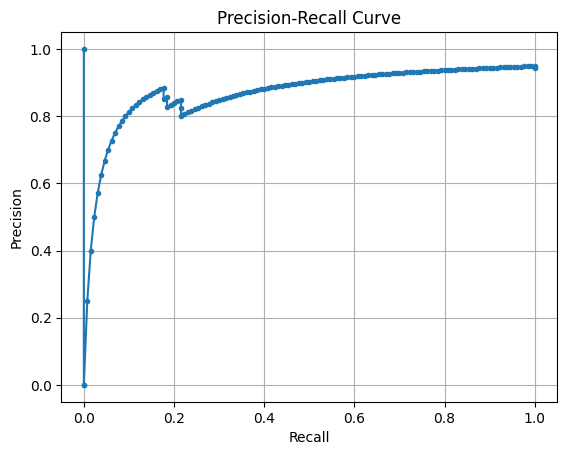

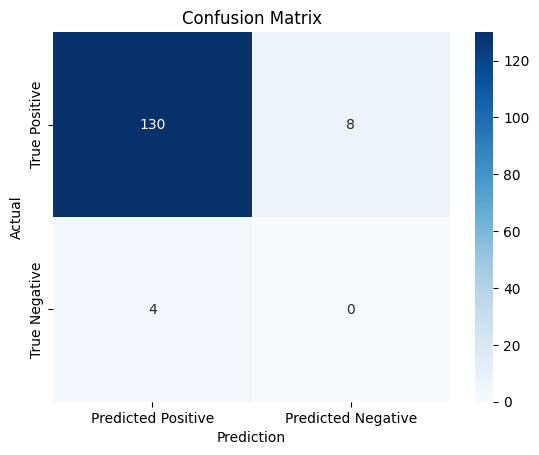

In [ ]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import seaborn as sns

def plot_results(img, boxes, names, save_path, image_name):
    for box in boxes:
        cls = int(box.cls.item())  # Convert class index to an integer
        conf = box.conf.item()  # Convert confidence score to a float
        xyxy = box.xyxy.squeeze().tolist()  # Convert bounding box to a list of integers
        label = names[cls]
        x1, y1, x2, y2 = map(int, xyxy)
        img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        img = cv2.putText(img, f'{label} {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Convert BGR to RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')

    # Save the image
    save_file = os.path.join(save_path, f"{image_name}.png")
    plt.savefig(save_file)
    plt.close()

def read_annotations(annotation_path):
    """
    Reads YOLO format annotations from a file.
    """
    bboxes = []
    with open(annotation_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                raise ValueError(f"Annotation line has an unexpected number of values: {parts}")
            class_id, x_center, y_center, width, height = map(float, parts)
            bboxes.append((class_id, x_center, y_center, width, height))
    return bboxes

def compute_auc_pr(predicted_boxes, ground_truth_boxes, class_count):
    """
    Compute the AUC for the Precision-Recall curve.
    """
    aucs = []
    for class_id in range(class_count):
        true_positives = []
        scores = []
        for pred_box in predicted_boxes:
            if int(pred_box[0]) != class_id:
                continue
            best_iou = 0
            for gt_box in ground_truth_boxes:
                if int(gt_box[0]) != class_id:
                    continue
                iou = calculate_iou(pred_box[1:5], gt_box[1:5])
                if iou > best_iou:
                    best_iou = iou
            true_positives.append(best_iou >= 0.5)
            scores.append(pred_box[4])

        precision, recall, _ = precision_recall_curve(true_positives, scores)
        auc_value = auc(recall, precision)
        aucs.append(auc_value)
    return np.mean(aucs), precision, recall

def compute_confusion_matrix(predicted_boxes, ground_truth_boxes, class_count, iou_threshold=0.5):
    """
    Compute the confusion matrix for object detection, including background.
    """
    tp = np.zeros(class_count + 1, dtype=int)  # +1 for background class
    fp = np.zeros(class_count + 1, dtype=int)
    fn = np.zeros(class_count + 1, dtype=int)
    tn = np.zeros(class_count + 1, dtype=int)

    # Track images with no detections
    images_with_detections = set()
    for box in predicted_boxes:
        image_id = box[-1]  # Assume image_id is stored in the last position of each box
        images_with_detections.add(image_id)

    for class_id in range(class_count + 1):  # Including background class
        gt_boxes = [box[1:5] for box in ground_truth_boxes if int(box[0]) == class_id]
        pred_boxes = [box[1:5] for box in predicted_boxes if int(box[0]) == class_id]
        pred_scores = [box[4] for box in predicted_boxes if int(box[0]) == class_id]

        assigned_gt = []
        for i, pred_box in enumerate(pred_boxes):
            best_iou = 0
            best_gt_idx = -1
            for j, gt_box in enumerate(gt_boxes):
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou and j not in assigned_gt:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold:
                tp[class_id] += 1
                assigned_gt.append(best_gt_idx)
            else:
                fp[class_id] += 1

        fn[class_id] = len(gt_boxes) - len(assigned_gt)

    # True negatives: total number of images - (true positives + false positives + false negatives)
    total_images = len(set(box[-1] for box in ground_truth_boxes).union(set(box[-1] for box in predicted_boxes)))
    tn[class_count] = total_images - sum(tp[:-1] + fp[:-1] + fn[:-1])

    return tp, fp, fn, tn
def convert_to_xyxy(box, img_shape):
    """
    Converts YOLO format box to (x1, y1, x2, y2).
    """
    class_id, x_center, y_center, width, height = box
    h, w = img_shape[:2]
    x_center, y_center, width, height = x_center * w, y_center * h, width * w, height * h
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return class_id, x1, y1, x2, y2

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    """
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0


def detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names):
    # Check if weights file exists
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weight file not found at {weights_path}")

    # Load the model
    model = YOLO(weights_path)

    # Run inference
    results = model(source_path)

    # Create directory to save results if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    all_pred_boxes = []
    all_gt_boxes = []

    # Visualize results
    for result in results:
        img = result.orig_img  # Get the original image
        boxes = result.boxes  # Get bounding boxes
        image_name = os.path.splitext(os.path.basename(result.path))[0]  # Get image name without extension
        plot_results(img, boxes, result.names, save_path, image_name)

        for box in boxes:
            cls = int(box.cls.item())
            conf = box.conf.item()
            xyxy = box.xyxy.squeeze().tolist()
            all_pred_boxes.append((cls, *xyxy, conf, image_name))

        annotation_file = os.path.join(annotations_path, f"{image_name}.txt")
        if os.path.exists(annotation_file):
            gt_boxes = read_annotations(annotation_file)
            gt_boxes = [convert_to_xyxy(box, img.shape) + (image_name,) for box in gt_boxes]
            all_gt_boxes.extend(gt_boxes)
        else:
            print(f"Warning: No annotation file found for {image_name}")

    # Calculate AUC for Precision-Recall curve
    auc_value, precision, recall = compute_auc_pr(all_pred_boxes, all_gt_boxes, class_count)
    print(f'Precision-Recall AUC: {auc_value:.4f}')

    # Calculate Confusion Matrix
    tp, fp, fn, tn = compute_confusion_matrix(all_pred_boxes, all_gt_boxes, class_count, iou_threshold=0.5)
    #print("Confusion Matrix:")
    #print(f"TP: {tp}")
    #print(f"FP: {fp}")
    #print(f"FN: {fn}")
    #print(f"TN: {tn}")

    for i in range(class_count + 1):  # Including background class
        class_label = class_names[i] if i < class_count else 'background'
        #print(f"Class {class_label} - TP: {tp[i]}, FP: {fp[i]}, FN: {fn[i]}, TN: {tn[i]}")

    # Plotting Precision-Recall curve
    plt.figure()
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid()
    plt.show()

    # Plotting Confusion Matrix
    cm = np.array([[tp[0], fp[0]], [fn[0], tn[0]]])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Predicted Positive', 'Predicted Negative'], yticklabels=['True Positive', 'True Negative'])
    plt.xlabel('Prediction')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == '__main__':
    # Path to the folder containing images for inference
    source_path = '/content/drive/MyDrive/gundetection6/dataset/images/testreal'
    # Path to save the resulting images
    save_path = '/content/drive/MyDrive/gundetection6/dataset/resultsreal'
    # Path to the folder containing annotation files
    annotations_path = '/content/drive/MyDrive/gundetection6/dataset/annotations'
    # Path to the weights file
    weights_path = '/content/drive/MyDrive/runs/detect/yolov8_custom/weights/best.pt'
    # Number of classes in the dataset
    class_count = 1  # Set this to the number of classes
    # Class names
    class_names = ["gun"]  # Update this with your class names

    detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names)


In [ ]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import seaborn as sns

def plot_results(img, boxes, names, save_path, image_name):
    for box in boxes:
        cls = int(box.cls.item())  # Convert class index to an integer
        conf = box.conf.item()  # Convert confidence score to a float
        xyxy = box.xyxy.squeeze().tolist()  # Convert bounding box to a list of integers
        label = names[cls]
        x1, y1, x2, y2 = map(int, xyxy)
        img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        img = cv2.putText(img, f'{label} {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Convert BGR to RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')

    # Save the image
    save_file = os.path.join(save_path, f"{image_name}.png")
    plt.savefig(save_file)
    plt.close()

def read_annotations(annotation_path):
    """
    Reads YOLO format annotations from a file.
    """
    bboxes = []
    with open(annotation_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                raise ValueError(f"Annotation line has an unexpected number of values: {parts}")
            class_id, x_center, y_center, width, height = map(float, parts)
            bboxes.append((class_id, x_center, y_center, width, height))
    return bboxes

def compute_auc_pr(predicted_boxes, ground_truth_boxes, class_count):
    """
    Compute the AUC for the Precision-Recall curve.
    """
    aucs = []
    precisions, recalls = [], []
    for class_id in range(class_count):
        true_positives = []
        scores = []
        for pred_box in predicted_boxes:
            if int(pred_box[0]) != class_id:
                continue
            best_iou = 0
            for gt_box in ground_truth_boxes:
                if int(gt_box[0]) != class_id:
                    continue
                iou = calculate_iou(pred_box[1:5], gt_box[1:5])
                if iou > best_iou:
                    best_iou = iou
            true_positives.append(best_iou >= 0.5)
            scores.append(pred_box[4])

        precision, recall, _ = precision_recall_curve(true_positives, scores)
        auc_value = auc(recall, precision)
        aucs.append(auc_value)
        precisions.append(precision)
        recalls.append(recall)
    return np.mean(aucs), precisions, recalls

def compute_confusion_matrix(predicted_boxes, ground_truth_boxes, class_count, iou_threshold=0.5):
    """
    Compute the confusion matrix for object detection, including background.
    """
    tp = np.zeros(class_count + 1, dtype=int)  # +1 for background class
    fp = np.zeros(class_count + 1, dtype=int)
    fn = np.zeros(class_count + 1, dtype=int)
    tn = np.zeros(class_count + 1, dtype=int)

    # Track images with no detections
    images_with_detections = set()
    for box in predicted_boxes:
        image_id = box[-1]  # Assume image_id is stored in the last position of each box
        images_with_detections.add(image_id)

    for class_id in range(class_count + 1):  # Including background class
        gt_boxes = [box[1:5] for box in ground_truth_boxes if int(box[0]) == class_id]
        pred_boxes = [box[1:5] for box in predicted_boxes if int(box[0]) == class_id]
        pred_scores = [box[4] for box in predicted_boxes if int(box[0]) == class_id]

        assigned_gt = []
        for i, pred_box in enumerate(pred_boxes):
            best_iou = 0
            best_gt_idx = -1
            for j, gt_box in enumerate(gt_boxes):
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou and j not in assigned_gt:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold:
                tp[class_id] += 1
                assigned_gt.append(best_gt_idx)
            else:
                fp[class_id] += 1

        fn[class_id] = len(gt_boxes) - len(assigned_gt)

    # True negatives: total number of images - (true positives + false positives + false negatives)
    total_images = len(set(box[-1] for box in ground_truth_boxes).union(set(box[-1] for box in predicted_boxes)))
    tn[class_count] = total_images - sum(tp[:-1] + fp[:-1] + fn[:-1])

    return tp, fp, fn, tn

def convert_to_xyxy(box, img_shape):
    """
    Converts YOLO format box to (x1, y1, x2, y2).
    """
    class_id, x_center, y_center, width, height = box
    h, w = img_shape[:2]
    x_center, y_center, width, height = x_center * w, y_center * h, width * w, height * h
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return class_id, x1, y1, x2, y2

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    """
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0

def detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names):
    # Check if weights file exists
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weight file not found at {weights_path}")

    # Load the model
    model = YOLO(weights_path)

    # Run inference
    results = model(source_path)

    # Create directory to save results if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    all_pred_boxes = []
    all_gt_boxes = []

    # Visualize results
    for result in results:
        img = result.orig_img  # Get the original image
        boxes = result.boxes  # Get bounding boxes
        image_name = os.path.splitext(os.path.basename(result.path))[0]  # Get image name without extension
        plot_results(img, boxes, result.names, save_path, image_name)

        for box in boxes:
            cls = int(box.cls.item())
            conf = box.conf.item()
            xyxy = box.xyxy.squeeze().tolist()
            all_pred_boxes.append((cls, *xyxy, conf, image_name))

        annotation_file = os.path.join(annotations_path, f"{image_name}.txt")
        if os.path.exists(annotation_file):
            gt_boxes = read_annotations(annotation_file)
            gt_boxes = [convert_to_xyxy(box, img.shape) + (image_name,) for box in gt_boxes]
            all_gt_boxes.extend(gt_boxes)
        else:
            print(f"Warning: No annotation file found for {image_name}")

    # Calculate AUC for Precision-Recall curve
    auc_value, precisions, recalls = compute_auc_pr(all_pred_boxes, all_gt_boxes, class_count)
    print(f'Precision-Recall AUC: {auc_value:.4f}')

    # Plotting and saving Precision-Recall curve
    plt.figure()
    for precision, recall in zip(precisions, recalls):
        plt.plot(recall, precision, marker='.', label=f'Class {class_names[precisions.index(precision)]}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (AUC = {auc_value:.4f})')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.savefig(os.path.join(save_path, "precision_recall_curve.png"))
    plt.close()

    # Calculate confusion matrix
    tp, fp, fn, tn = compute_confusion_matrix(all_pred_boxes, all_gt_boxes, class_count)
    confusion_mtx = np.array([tp[:-1], fp[:-1], fn[:-1]]).T  # Exclude background class from confusion matrix

    # Plotting and saving confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=['TP', 'FP', 'FN'], yticklabels=class_names)
    plt.xlabel('Prediction')
    plt.ylabel('True Class')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(save_path, "confusion_matrix.png"))
    plt.close()

    print(f"Results saved to {save_path}")

if __name__ == '__main__':
    # Path to the folder containing images for inference
    source_path = '/content/drive/MyDrive/gundetection6/dataset/images/test'
    # Path to save the resulting images
    save_path = '/content/drive/MyDrive/gundetection6/dataset/results1'
    # Path to the folder containing annotation files
    annotations_path = '/content/drive/MyDrive/gundetection6/dataset/annotations'
    # Path to the weights file
    weights_path = '/content/drive/MyDrive/runs/detect/yolov8_custom/weights/best.pt'
    # Number of classes in the dataset
    class_count = 1  # Set this to the number of classes
    # Class names
    class_names = ["gun"]  # Update this with your class names

    detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names)


image 1/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image141.jpg: 640x480 1 Gun, 408.6ms
image 2/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image142.jpg: 640x480 1 Gun, 836.3ms
image 3/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image143.jpg: 640x480 1 Gun, 286.3ms
image 4/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image144.jpg: 640x480 1 Gun, 248.3ms
image 5/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image145.jpg: 640x480 1 Gun, 240.0ms
image 6/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image146.jpg: 640x480 1 Gun, 176.6ms
image 7/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image147.jpg: 640x480 1 Gun, 160.4ms
image 8/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image148.jpg: 640x480 1 Gun, 162.3ms
image 9/171 /content/drive/MyDrive/gundetection6/dataset/images/test/image149.jpg: 640x480 1 Gun, 156.8ms
image 10/171 /content/drive/MyDrive/gundetect

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
from ultralytics import YOLO

def plot_results(img, boxes, names, save_path, image_name):
    for box in boxes:
        cls = int(box.cls.item())  # Convert class index to an integer
        conf = box.conf.item()  # Convert confidence score to a float
        xyxy = box.xyxy.squeeze().tolist()  # Convert bounding box to a list of floats
        label = names[cls]
        x1, y1, x2, y2 = map(int, xyxy)
        img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        img = cv2.putText(img, f'{label} {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Convert BGR to RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')

    # Save the image
    save_file = os.path.join(save_path, f"{image_name}.png")
    plt.savefig(save_file)
    plt.close()

def read_annotations(annotation_path):
    """
    Reads YOLO format annotations from a file.
    """
    bboxes = []
    with open(annotation_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                raise ValueError(f"Annotation line has an unexpected number of values: {parts}")
            class_id, x_center, y_center, width, height = map(float, parts)
            bboxes.append((class_id, x_center, y_center, width, height))
    return bboxes

def convert_to_xyxy(box, img_shape):
    """
    Converts YOLO format box to (x1, y1, x2, y2).
    """
    class_id, x_center, y_center, width, height = box
    h, w = img_shape[:2]
    x_center, y_center, width, height = x_center * w, y_center * h, width * w, height * h
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return class_id, x1, y1, x2, y2

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    """
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0

def compute_ap(pred_boxes, gt_boxes, class_id, iou_threshold=0.5):
    """
    Compute average precision for a given class.
    """
    true_positives = []
    false_positives = []
    scores = []
    num_gt_boxes = sum(1 for box in gt_boxes if int(box[0]) == class_id)

    for pred_box in pred_boxes:
        if int(pred_box[0]) != class_id:
            continue

        best_iou = 0
        best_gt_idx = -1
        for gt_idx, gt_box in enumerate(gt_boxes):
            if int(gt_box[0]) != class_id:
                continue

            iou = calculate_iou(pred_box[1:5], gt_box[1:5])  # Unpack only 4 values (coordinates)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            true_positives.append(1)
            false_positives.append(0)
        else:
            true_positives.append(0)
            false_positives.append(1)

        scores.append(pred_box[5])  # Ensure score is included

    if num_gt_boxes == 0:
        return 0

    sorted_indices = np.argsort(scores)[::-1]
    true_positives = np.array(true_positives)[sorted_indices]
    false_positives = np.array(false_positives)[sorted_indices]

    cum_tp = np.cumsum(true_positives)
    cum_fp = np.cumsum(false_positives)
    precision = cum_tp / (cum_tp + cum_fp)
    recall = cum_tp / num_gt_boxes

    ap = average_precision_score(true_positives, scores) if num_gt_boxes > 0 else 0
    return ap

def compute_map(predicted_boxes, ground_truth_boxes, class_count, iou_thresholds=[0.5]):
    """
    Compute the mean Average Precision (mAP) across different IoU thresholds.
    """
    aps = {iou_threshold: [] for iou_threshold in iou_thresholds}

    for class_id in range(class_count):
        for iou_threshold in iou_thresholds:
            ap = compute_ap(predicted_boxes, ground_truth_boxes, class_id, iou_threshold)
            aps[iou_threshold].append(ap)

    mean_aps = {iou_threshold: np.mean(aps[iou_threshold]) for iou_threshold in iou_thresholds}
    return mean_aps

def detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names, iou_threshold=0.5):
    # Load the model
    model = YOLO(weights_path)

    # Run inference
    results = model(source_path)

    # Create directory to save results if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    all_pred_boxes = []
    all_gt_boxes = []

    # Visualize results and collect predicted and ground truth boxes
    for result in results:
        img = result.orig_img  # Get the original image
        boxes = result.boxes  # Get bounding boxes
        image_name = os.path.splitext(os.path.basename(result.path))[0]  # Get image name without extension

        plot_results(img, boxes, result.names, save_path, image_name)

        pred_boxes = [(int(box.cls.item()), *box.xyxy.squeeze().tolist(), box.conf.item()) for box in boxes]  # Include score
        all_pred_boxes.extend(pred_boxes)

        annotation_file = os.path.join(annotations_path, f"{image_name}.txt")
        if os.path.exists(annotation_file):
            gt_boxes = read_annotations(annotation_file)
            gt_boxes = [convert_to_xyxy(box, img.shape) for box in gt_boxes]
            all_gt_boxes.extend(gt_boxes)
        else:
            print(f"Warning: No annotation file found for {image_name}")


    # Calculate  mAP
    mean_aps = compute_map(all_pred_boxes, all_gt_boxes, class_count, iou_thresholds=[0.5])
    for iou_threshold, map_value in mean_aps.items():
        print(f'mAP@{iou_threshold}: {map_value:.4f}')

if __name__ == '__main__':
    # Path to the folder containing images for inference
    source_path = '/content/drive/MyDrive/gundetection6/dataset/images/testreal'
    # Path to annotations
    annotations_path = '/content/drive/MyDrive/gundetection6/dataset/annotations'
    # Path to the weights file
    weights_path = '/content/drive/MyDrive/runs/detect/yolov8_custom/weights/best.pt'
    # Number of classes (including background)
    class_count = 1  # Update this based on the number of classes in your dataset
    # Class names
    class_names = ['Gun', 'Background']  # Update this based on your dataset

    detect_yolo_and_evaluate(source_path, annotations_path, '/content/drive/MyDrive/gundetection6/dataset/resultsreal', weights_path, class_count, class_names)



image 1/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image141.jpg: 640x480 1 Gun, 263.9ms
image 2/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image142.jpg: 640x480 1 Gun, 454.8ms
image 3/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image143.jpg: 640x480 1 Gun, 245.4ms
image 4/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image144.jpg: 640x480 1 Gun, 230.0ms
image 5/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image145.jpg: 640x480 1 Gun, 271.9ms
image 6/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image146.jpg: 640x480 1 Gun, 239.3ms
image 7/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image147.jpg: 640x480 1 Gun, 235.2ms
image 8/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image148.jpg: 640x480 1 Gun, 232.1ms
image 9/171 /content/drive/MyDrive/gundetection6/dataset/images/testreal/image149.jpg: 640x480 1 Gun, 188.6ms
image 10/